# TN2211 Session 4

## Instruments

In [1]:
import sys
sys.path.append("../drivers/")
from tn2211_drivers import *
import glob
import matplotlib.pyplot as plt

Loading BokehJS ...

In [2]:
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'USB0::0xF4EC::0x1103::SDG1XDDX802455::INSTR',
 'USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR')

In [5]:
scope = Scope("SDS")

Connecting to scope at resource: USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR
Setting memory depth to 10k points


In [ ]:
scope.get_screenshot()

In [5]:
t,v = scope.get_trace(1)

Retreiving 10000 points


In [6]:
gen = Generator("SDG")

Connecting to scope at resource: USB0::0xF4EC::0x1103::SDG1XDDX802455::INSTR


In [ ]:
gen.set_frequency(1,10e3)

In [ ]:
gen.get_screenshot()

In [ ]:
help(gen)

## Calculator 

It is always handy to have some code cells to do quick calculations for you. 

In [12]:
R = 1e3 # Ohms
C = 10e-9 # Farads

w_c = 1/R/C
f_c = w_c / 2 / np.pi

print("Corner frequency: %.2e Hz" % f_c)

Corner frequency: 1.59e+04 Hz


In [ ]:
# add cells as needed for your calculations

In [ ]:
# more calculations

## Frequency sweep traces

Some code to help analyze the data from the "chirp" frequency sweeps.

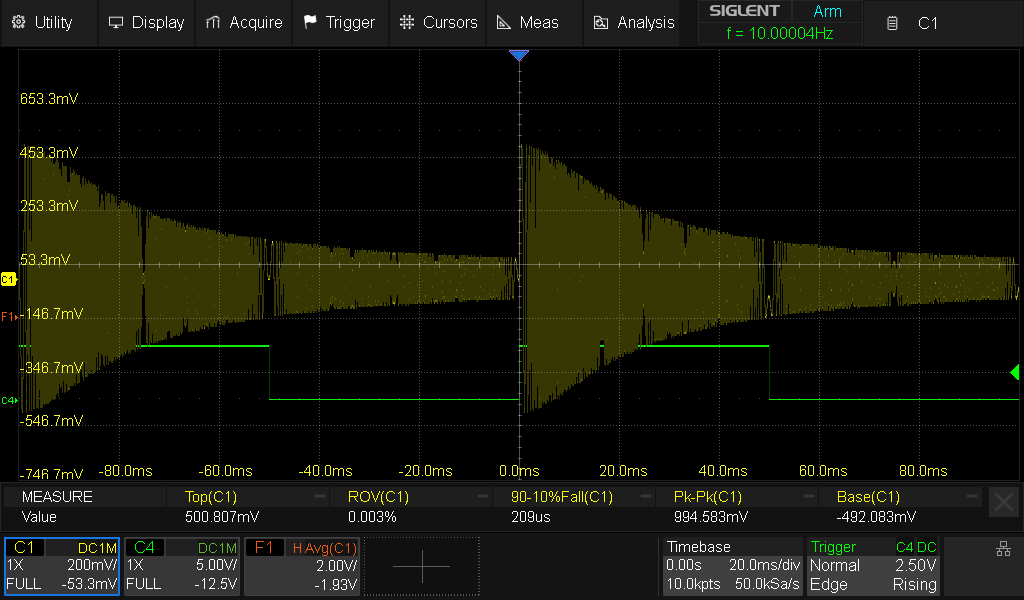

In [50]:
scope.get_screenshot()

In [51]:
t,v = scope.get_trace(1)

Retreiving 10000 points


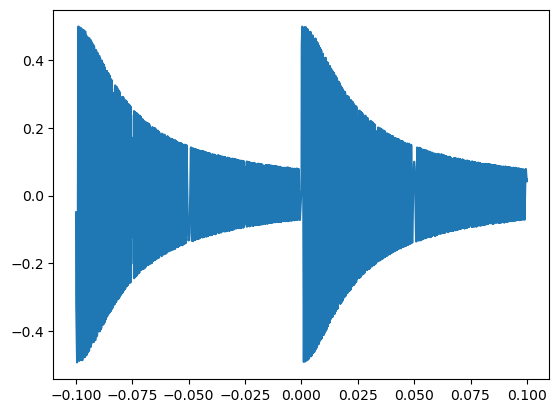

In [52]:
plt.plot(t,v)

I have programmed the generator with a 100 ms sweep, set the horizontal offset to zero on the scope, and set the scope to 20 ms/div, giving me time in the trace running from t = -100 ms to t = 100 ms. Therefore, the second half of my array should line up with the frequency sweep (which it does visually). I have configured a sweep from 100 Hz to 100 kHz. 

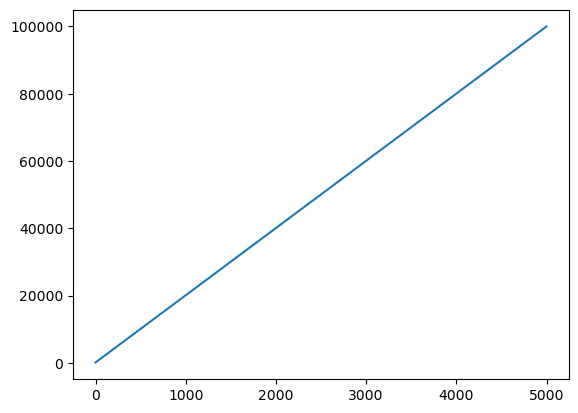

In [53]:
# Construct the frequency sweep array

N = len(t)
t_sweep = t[N//2:]
f_start = 100 # Hz
f_stop = 100e3 # Hz
f = f_start + (f_stop - f_start)/t_sweep[-1]*t_sweep

plt.plot(f)

In [54]:
R = # your fixed r value in ohms
C = np.array([xxx, xxx, xxx, xxx]) # your C values in farads

tau_predicted = R*C

t_10_90_measured = np.zeros(4)
t_10_90_measured[0] =  xxx # seconds
t_10_90_measured[1] =  xxx # seconds
t_10_90_measured[2] =  xxx # seconds
t_10_90_measured[3] =  xxx # seconds

tau_meas = t_10_90_measured / 2.2

plt.title("R = %e ohms", R) # handy for documenting
plt.plot(C, tau_meas, 'o', label="...")
plt.plot(C, tau_predicted, '-', label="...")
plt.legend()
# add labels etc


SyntaxError: invalid syntax (2700776100.py, line 1)

Text(0, 0.5, 'V_meas')

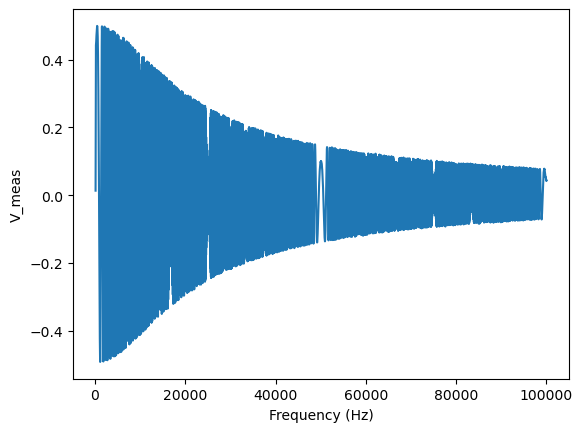

In [55]:
V_meas = v[N//2:]

plt.plot(f, V_meas)
plt.xlabel("Frequency (Hz)")
plt.ylabel("V_meas")

Retreiving 10000 points


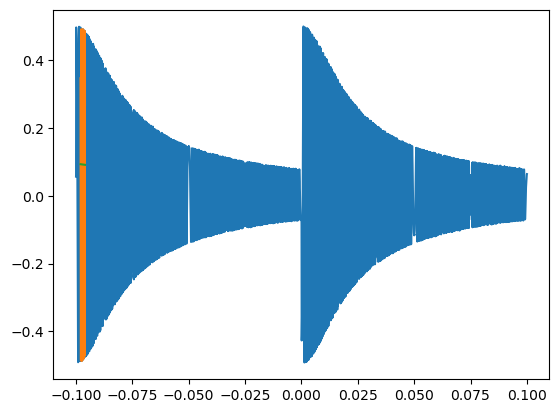

In [56]:
t,v = scope.get_trace(1)

i1 = 100 # where to start slicing the data, the point at which you think the model starts to apply
i2 = 200 # the last bit of the data to fit

def v_model(t, V0, t0, tau, Voff):
    return V0*(1-np.exp((t-t0)/tau)) + Voff

t_fit = t[i1:i2]
v_fit = v[i1:i2]

# Initial guess

V0 = 1 # V
t0 = 0 # seconds
tau = 1 # seconds
Voff = 0 # V

plt.plot(t,v, label="Full trace") # the full trace
plt.plot(t_fit, v_fit, label="Fitted region") # the data we slice out to fit
plt.plot(t_fit, v_model(t_fit, V0, t0, tau, Voff), label="Iniital guess") 

In [57]:
from scipy.signal import find_peaks

In [58]:
# Find the peak of the absolute values as an approximation of the amplitude
peak_positions, _ = find_peaks(np.abs(V_meas))

In [59]:
peak_positions

array([  17,   51,   71, ..., 4976, 4990, 4994], shape=(1336,))

In [60]:
amp = np.abs(V_meas[peak_positions])
f_amp = f[peak_positions]

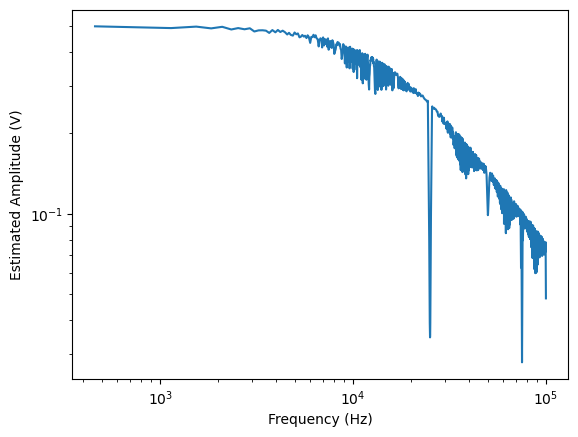

In [61]:
plt.plot(f_amp, amp)
plt.ylabel("Estimated Amplitude (V)")
plt.xlabel("Frequency (Hz)")
plt.yscale("log")
plt.xscale("log")

Looks not too bad

Things to try to make it better: 

* Longer sweep time
* More memory depth (need to override default value in get_trace, it will take longer to download your trace)
* Try "Peak detect" mode as acquisition method?  https://www.google.com/search?q=peak+detect+mode
* Take multiple traces, average the square amplitudes, take the square root, then plot


# Programming the generator and scope in a loop

Here, you can get "more control"! If you really want the exact amplitude and phase for different frequencies, you can program the generator in a for loop to set a frequency, then measure on the scope the trace, then set the next frequency, and measure the next trace. 

Note that if you want to change the frequency by a lot, you will also need to have your for-loop change the timebase of your scope in order to match close enough your generator frequency so that you get multiple oscillations in your measured trace and you can do a decent analysis of the frequency. For this, you will have to look up the programming manual of the scope (see https://nsweb.tn.tudelft.nl/~gsteele/tn2211/), find out what the SCPI commands you need for changing the timebase, and then send those to the scope using the `write()` function that is built into the scope object class. 

In [21]:
# Now run curve fit (scipy is good, lmfit is even better), 
# replot with fitted data, look at fit values, errors, and covariance

# your code

In our simple funciton above, we already have 4 free fit parmaters! Free fit parameters are bad in general because you can often end up in a "local minimum" where your function fits the data well but might be (far?) off from the actual underlying physical parameters of your circuit.

One way to solve this is ot use **independent** measurements to separately fix parameters and then rewrite a different free parameters. (In [scipy curve_fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html), you have to write a new function with fewer parameters, while the [lmfit library](https://lmfit.github.io/lmfit-py/model.html) allows you to resuse the same function and the specify which parameters of your fit should be "free" and which should be fixed.)

If your square pulse period is long enough, you can extract the offset voltage by slicing out points that you know are after the transient has settled and then using np.average(). Similarly, if you want to get an accurate estimate of `t0`, you could enable a second channel on your scope and use a jumper on your PCB to *measure* the square pulse applied to your circuit and download it to python to determine accurately the switching time. 

In [22]:
# Try a fit where you independently fix Voff and t0, document how you get these values!

# your code